In [ ]:
import boto3
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
s3 = boto3.client('s3')
bucket = 'cust-seg-ygp'
key = 'rfm_scaled.csv'   # <-- scaled file name

obj = s3.get_object(Bucket=bucket, Key=key)
rfm_scaled = pd.read_csv(obj['Body'])

rfm_scaled.head()

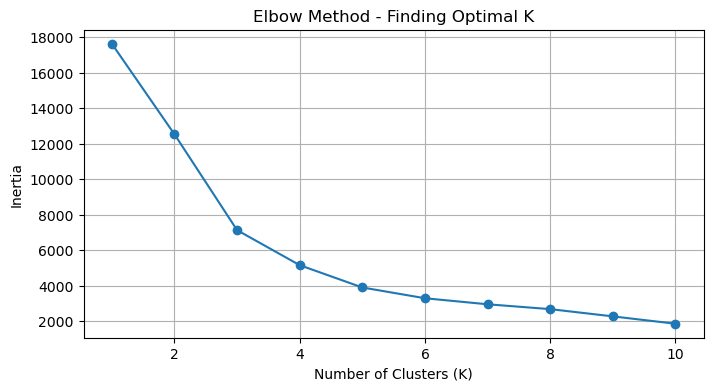

In [ ]:
# Use ONLY the scaled RFM features
X = rfm_scaled[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']]

inertia_list = []      # to store inertia values
K_range = range(1, 11)  # test K = 1 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia_list.append(kmeans.inertia_)   # lower inertia = better fit

# Plot
plt.figure(figsize=(8,4))
plt.plot(K_range, inertia_list, marker='o')
plt.title('Elbow Method - Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()